In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
plt.rcParams['text.usetex'] = True
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath,amssymb}'
from PIL import Image

# **Generating $n>d$ vectors in $\mathbb{R}^d$ almost orthonormal**
In $d$-dimensions there are at most $d$ unit vectors that are pairwise orthogonal. However, if you wanted a set of vectors that were "almost orthogonal" you might squeeze in a few more. For example, in 2-dimensions if you wanted vectors at least 45 degrees apart, then you could fit in three vectors. Suppose you wanted to find 1000 almost orthogonal vectors in 100 dimensions. Here are two ways you could try doing it:

(a) Begin with 1000 orthonormal 1000-dimensional vectors, and then project them to a random 100-dimensional space. (Your random projection may be generated by forming a 1000 $\times$ 100 matrix $\mathbf{M}$ with iid $\mathcal{N}(0,1)$ entries, taking the $\mathbf{Q}$ factor in the thin QR decomposition of $\mathbf{M}$ and then projecting via $\mathbf{Q}^{\top}$).

(b) Generate 1000 100-dimensional random standard Gaussian vectors

In [4]:
def generate_vectors_part_a(rows, cols):
    #N(0,1) matrix
    #x[i,j] = row i column j  
    x = np.random.normal(0.0, 1.0, size=(rows, cols))

    Q = np.zeros((rows, cols))
    
    #Gram-schmidt, creates Q = [q1|q2|...|qcols] where the qi are the orthonormal basis
    for j in range(cols):
        v = x[:, j].copy()  # take the j-th column
        
        # Subtract the projections onto previous Q columns
        for i in range(j):
            v -= np.dot(Q[:, i], v) * Q[:, i]
        
        # Normalize
        norm = np.linalg.norm(v)
        Q[:, j] = v / norm

    #We can pick 1000 orthonormal 1000 dimensional vectors by (1,0,...,0), (0,1,0,...,0), ... , (0,0,...,1).
    #When projected via Q-transpose, each component is essentially sent to a column of Q-transpose. So
    v = Q.T

    #normalize the columns of v so inner product yields cos(angle) directly
    v = v / np.linalg.norm(v, axis=0, keepdims=True)
    cosangles = v.T @ v 
    return v, cosangles

def generate_vectors_part_b(dim, numvecs):
    #N(0,1) matrix  
    #x[i,j] = ith component of jth vector
    x = np.random.normal(0.0, 1.0, size=(dim, numvecs))

    #normalize x to put inner product in more convenient form
    x = x / np.linalg.norm(x, axis=0, keepdims=True)
    
    cosangles = x.T @ x 
    return x, cosangles

#Generate 1000 almost orthogonal vectors in 100 dimensions by method in part a
vecs_parta, costhetas_parta = generate_vectors_part_a(1000,100)
np.fill_diagonal(costhetas_parta, np.nan)

#Generate 1000 almost orthogonal vectors in 100 dimensions by method in part b
vecs_partb, costhetas_partb = generate_vectors_part_b(100,1000)
np.fill_diagonal(costhetas_partb, np.nan)


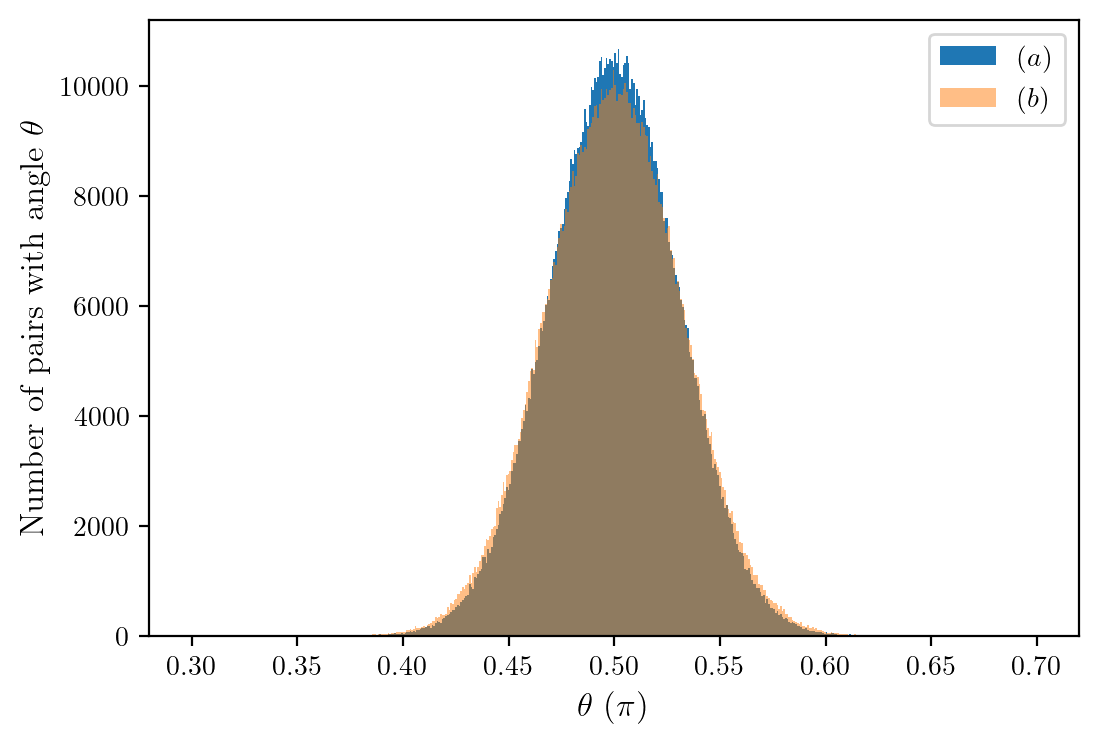

In [5]:
plt.figure(figsize=(6,4), dpi=200)
# Define common bin edges
bins = np.linspace(0.3, 0.7, 501)  # 100 bins between 0 and π
plt.hist(np.arccos(costhetas_parta.flatten())/math.pi, bins=bins, density=False, label="$(a)$");
plt.hist(np.arccos(costhetas_partb.flatten())/math.pi, bins=bins, alpha=0.5, density=False, label="$(b)$");
#axes[1].hist(d2.flatten(), bins=50, density=False)
plt.ylabel("Number of pairs with angle $\\theta$", fontsize=12);
plt.xlabel("$\\theta$ ($\\pi$)", fontsize=12);
plt.legend(fontsize=10)